# Sabine nomination-revision intraday overlay — final research specification

This notebook is the presentation and reproduction layer for the final Sabine dominant nomination-revision intraday overlay. It creates a temporary position after the Intraday 3 posting and closes that incremental position at the same trading day's NYMEX settlement. It is an isolated research overlay: it does not modify V03, create a formal V04, or overwrite the earlier exploratory nomination artifacts.

The notebook also retains a deliberately weaker timing comparator. That comparator uses the same signal only in the next confirmed session's normal settlement-to-settlement position and does not trade the I3-to-settlement window.

On a clean checkout, the first code cell materializes the exact generation-pinned nomination panel, execution windows, and raw all-cycle OAC archive declared in `manifests/sabine_nomination_overlay_inputs_2026-08-19.json` into the ignored `inputs/gcs` cache. Private-bucket read access is required. For the independent raw-OAC factor-parity receipt and atomic `reproduced/` output, run `python -m naturalgas.pipelines.rebuild_sabine_nomination_overlay --overwrite`. Raw NYMEX ticks are controlled and are represented here by their pinned processed execution-window contract.

In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'naturalgas/evaluate_sabine_nomination_revision_intraday_overlay_final.py').exists():
    raise FileNotFoundError('Run from the Henry Hub repository or its notebooks directory.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from naturalgas.evaluate_sabine_nomination_revision_intraday_overlay_final import (
    DEFAULT_OUTPUT_DIR,
    run,
)

summary = run()
OUTPUT_DIR = DEFAULT_OUTPUT_DIR
print(f"Final research artifacts: {OUTPUT_DIR}")
print(f"Active window: {str(summary['active_evaluation']['start'])[:10]} to {str(summary['active_evaluation']['end'])[:10]}")
print(f"Eligible I3 events: {summary['active_evaluation']['events']:,}")

Final research artifacts: /home/syang_braeswoodcarbon_com/2026-intern-projects/henry-hub-natural-gas/results/experiments/sabine_nomination_revision_intraday_overlay_final
Active window: 2023-10-23 to 2026-07-13
Eligible I3 events: 635


## Frozen strategy definition

Two physical revisions compete each gas day: TransCameron LNG delivery from Intraday 1 to Intraday 3, and Jefferson Island injection minus withdrawal from Timely to Intraday 3. Each is standardized against strictly earlier gas days with a 60-observation minimum. The revision with the larger absolute z-score sets the sign and magnitude of the temporary sleeve:

$$\Delta P_t=0.10\tanh(z_t^*).$$

Execution is part of the signal definition. The entry is the actual held NG contract's trade VWAP from I3 posting +5 through +30 minutes. The incremental sleeve exits at the same contract's settlement-window VWAP and pays 2.5 bps per unit on each leg.

In [2]:
definition = pd.Series(summary['strategy_definition'], name='Final specification').to_frame()
display(definition)

,Final specification
lng_revision,"TransCameron delivery, Intraday 1 to Intraday 3"
storage_revision,"Jefferson Island injection minus withdrawal, T..."
standardization,causal expanding z-score with 60 prior gas days
selection,"larger absolute z-score, economic sign preserved"
temporary_position,0.10 * tanh(selected revision z)
entry,held NG contract trade VWAP from I3 posting +5...
exit,same contract settlement-window VWAP
contract,V03 held contract: C2 during the five-session ...
cost,2.5 bps per unit on entry and 2.5 bps per unit...


## Headline active-window result

All three rows use the same 682 trading dates. The selected overlay adds only the post-I3 temporary trade. The next-session row removes that trade and shifts the same incremental signal into the following normal V03 position.

In [3]:
headline = pd.read_csv(OUTPUT_DIR / 'headline_metrics.csv', parse_dates=['start', 'end'])
active = headline.loc[headline['sample'].eq('active_overlap')].copy()
active['variant'] = active['variant'].map({
    'base_v03': 'Base V03',
    'selected_intraday_overlay': 'Selected intraday overlay',
    'next_session_only_comparator': 'Next-session-only comparator',
})
shown = active.set_index('variant')[[
    'trading_days', 'sharpe', 'sortino', 'cagr', 'total_return',
    'maximum_drawdown', 'annualized_downside_deviation'
]]
display(shown.style.format({
    'trading_days': '{:,.0f}', 'sharpe': '{:.3f}', 'sortino': '{:.3f}',
    'cagr': '{:.2%}', 'total_return': '{:.2%}',
    'maximum_drawdown': '{:.2%}',
    'annualized_downside_deviation': '{:.2%}',
}))

,trading_days,sharpe,sortino,cagr,total_return,maximum_drawdown,annualized_downside_deviation
variant,,,,,,,
Base V03,682,1.960,3.362,15.31%,47.36%,-3.94%,4.26%
Selected intraday overlay,682,2.453,4.334,20.32%,65.42%,-3.10%,4.29%
Next-session-only comparator,682,1.331,2.104,10.13%,30.03%,-7.87%,4.61%


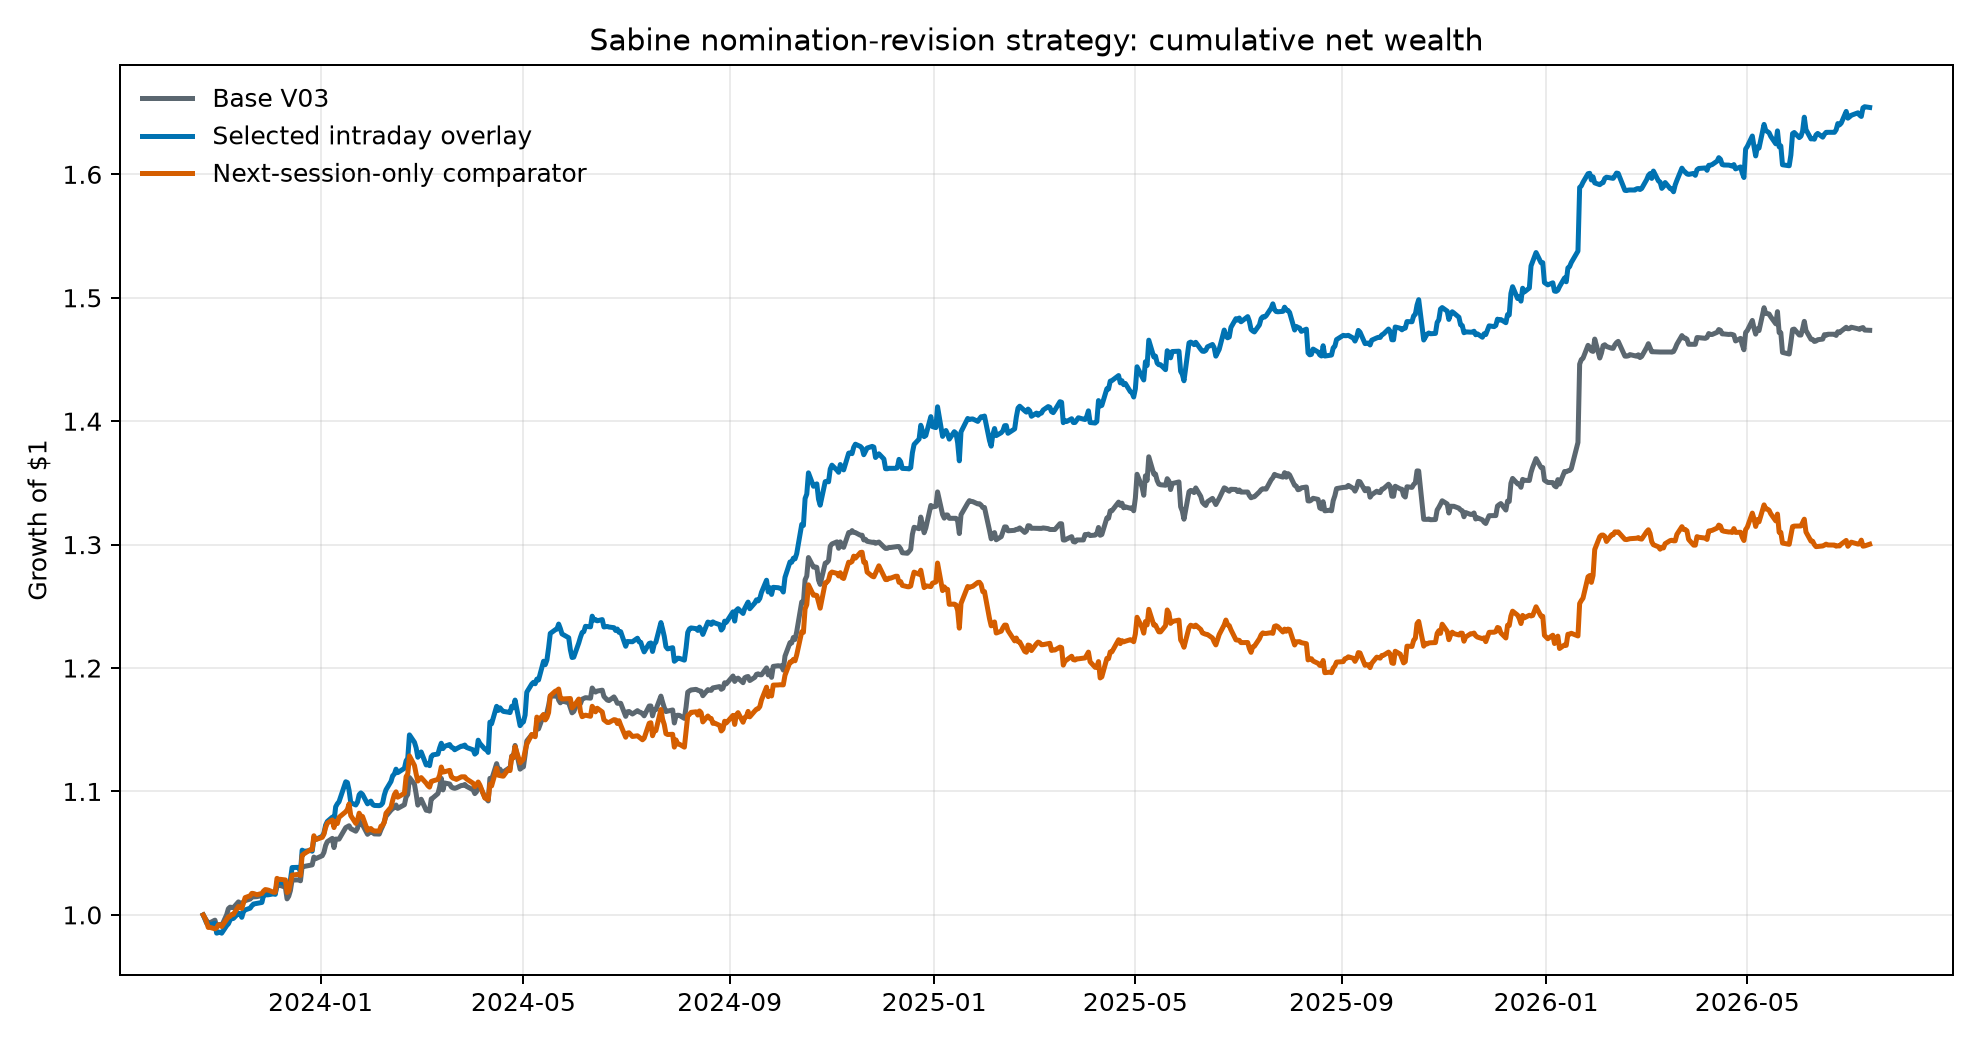

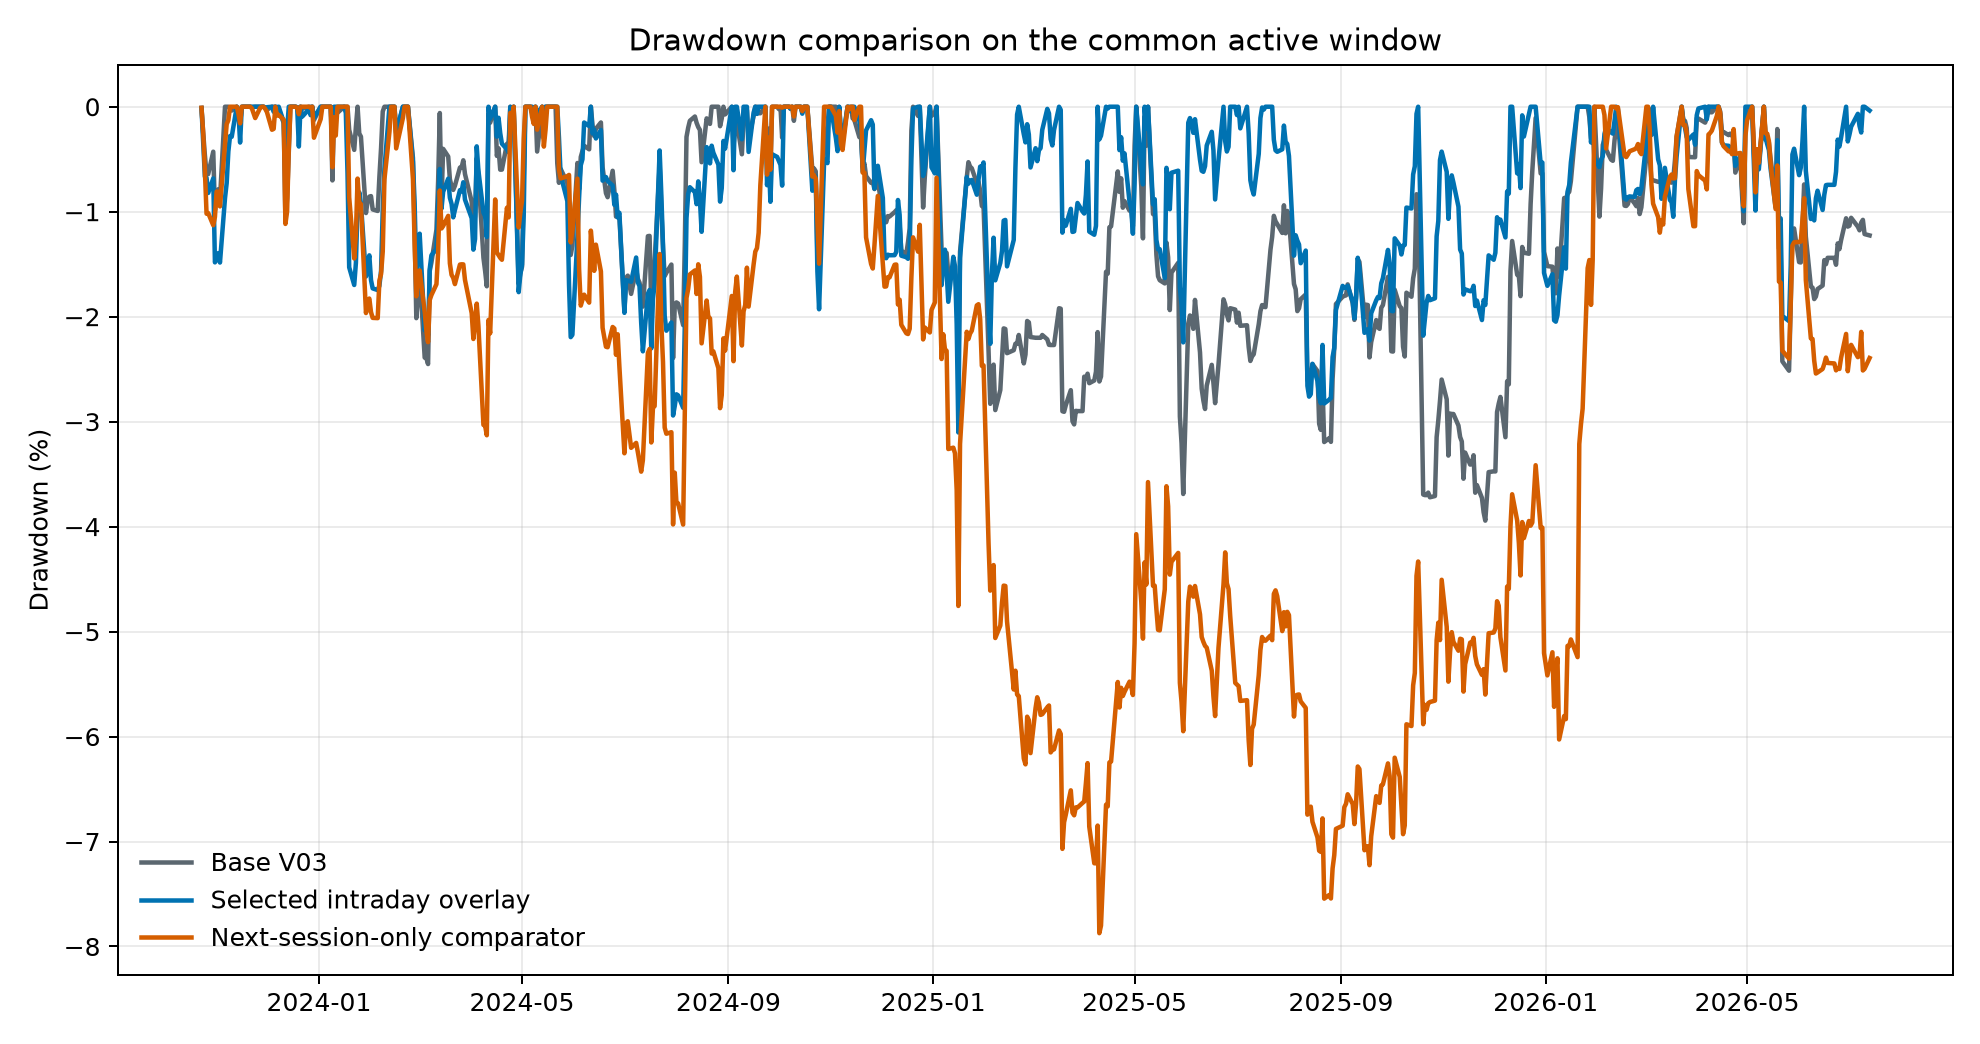

In [4]:
display(Image(filename=str(OUTPUT_DIR / 'cumulative_net_wealth.png')))
display(Image(filename=str(OUTPUT_DIR / 'drawdown_comparison.png')))

## Why the execution window matters

The selected implementation raises active-window Sharpe from 1.960 to 2.453 and reduces maximum drawdown from 3.94% to 3.10%. Waiting until the next normal position interval lowers Sharpe to 1.331 and increases maximum drawdown to 7.87%. The signal therefore behaves historically like short-lived information around the I3 posting, not like a durable next-day state variable.

,year,events,base_sharpe,intraday_sharpe,next_session_sharpe,intraday_delta_sharpe,next_session_delta_sharpe,intraday_incremental_net_sum_bps,next_session_incremental_net_sum_bps
0,2023,48,4.325,4.675,4.760,+0.350,+0.435,+149.2,+148.5
1,2024,227,3.265,3.383,2.333,+0.118,-0.932,+335.3,-621.2
2,2025,232,0.234,1.078,-0.462,+0.844,-0.696,+646.3,-497.1
3,2026,128,1.981,2.462,1.723,+0.480,-0.258,+31.2,-282.6


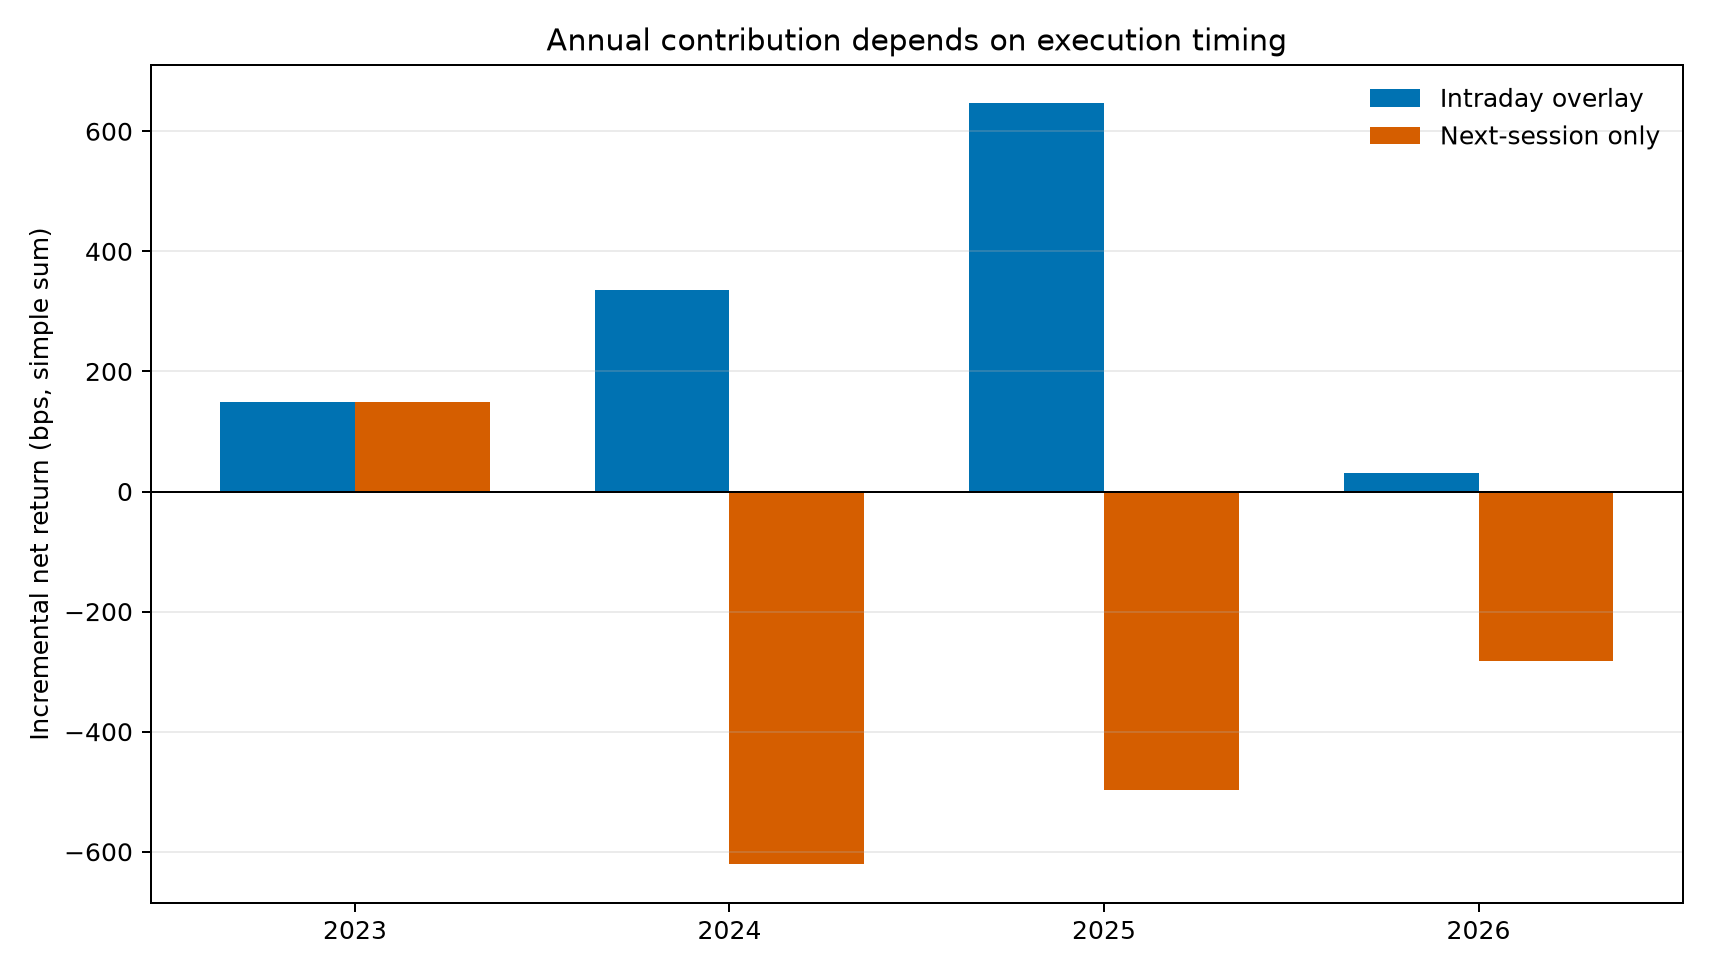

In [5]:
annual = pd.read_csv(OUTPUT_DIR / 'annual_attribution.csv')
display(annual.style.format({
    'base_sharpe': '{:.3f}', 'intraday_sharpe': '{:.3f}',
    'next_session_sharpe': '{:.3f}', 'intraday_delta_sharpe': '{:+.3f}',
    'next_session_delta_sharpe': '{:+.3f}',
    'intraday_incremental_net_sum_bps': '{:+,.1f}',
    'next_session_incremental_net_sum_bps': '{:+,.1f}',
}))
display(Image(filename=str(OUTPUT_DIR / 'annual_incremental_contribution.png')))

## Source attribution and robustness

The final name *dominant revision* is literal: LNG and storage are standardized separately, and the larger absolute move is selected without changing its sign. Both channels contribute positively. The comparison below also shows that the result persists across nearby causal-history choices and moderate increases in the fixed execution-cost assumption.

,selected_source,events,mean_absolute_incremental_position,incremental_net_sum_bps,positive_incremental_return_share
0,LNG,161,5.72%,+749.8,54.0%
1,Storage,474,5.88%,+412.2,52.3%


,formulation,events,delta_sharpe,delta_total_return,incremental_net_sum_bps
0,lng,635,+0.193,+10.24%,+682.2
1,storage,635,+0.240,+6.38%,+422.6
2,equal,635,+0.306,+8.86%,+583.3
3,dominant,635,+0.493,+18.06%,"+1,162.0"


,minimum_prior_gas_days,start,events,delta_sharpe,delta_total_return,incremental_net_sum_bps
0,20,2023-09-11,662,+0.416,+16.44%,"+1,052.1"
1,60,2023-10-23,635,+0.493,+18.06%,"+1,162.0"
2,120,2023-12-26,591,+0.481,+15.52%,"+1,043.7"


,cost_bps_per_leg_per_unit,delta_sharpe,delta_total_return,incremental_net_sum_bps
0,2.500000,+0.493,+18.06%,"+1,162.0"
1,5.000000,+0.403,+15.02%,+976.7
2,10.000000,+0.222,+9.11%,+605.9
3,20.000000,-0.139,-2.06%,-135.5


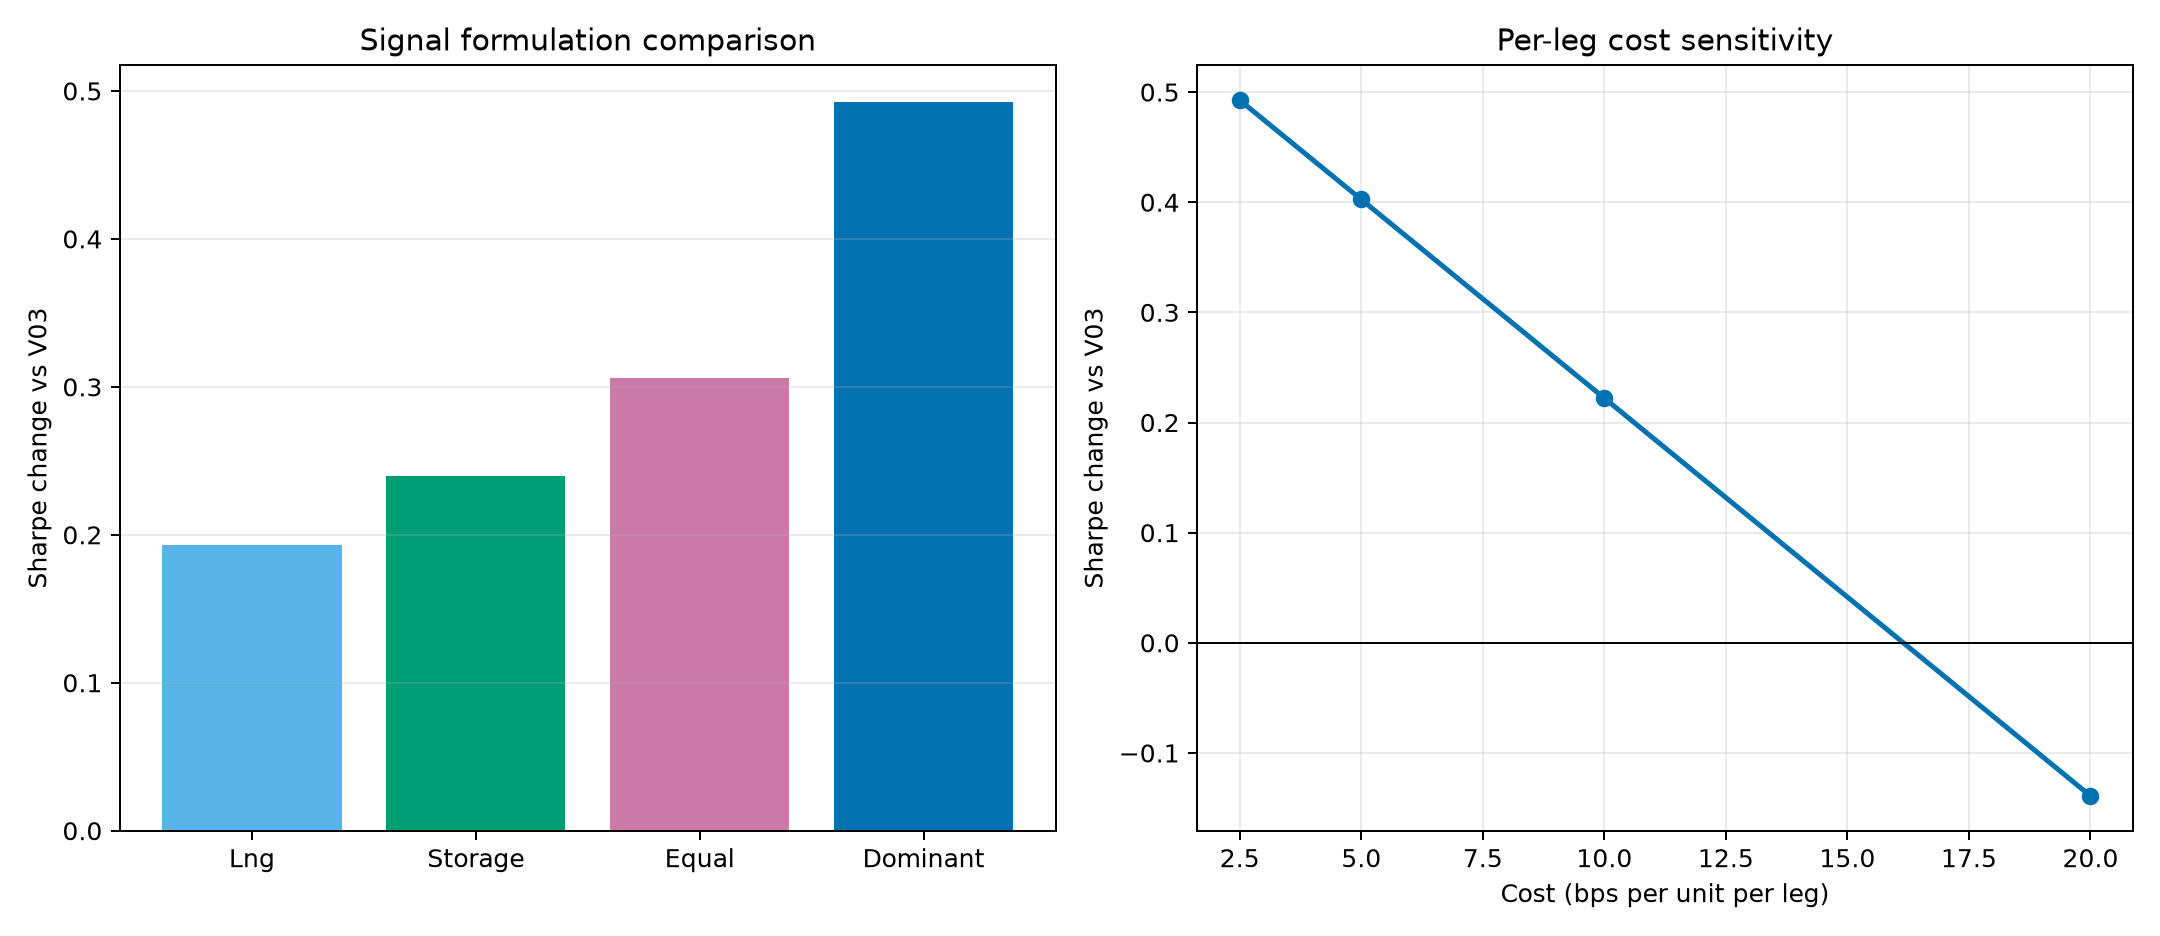

In [6]:
source = pd.read_csv(OUTPUT_DIR / 'source_attribution.csv')
formulation = pd.read_csv(OUTPUT_DIR / 'formulation_comparison.csv')
history = pd.read_csv(OUTPUT_DIR / 'history_sensitivity.csv')
cost = pd.read_csv(OUTPUT_DIR / 'cost_sensitivity.csv')

display(source.style.format({
    'mean_absolute_incremental_position': '{:.2%}',
    'incremental_net_sum_bps': '{:+,.1f}',
    'positive_incremental_return_share': '{:.1%}',
}))
display(formulation.style.format({
    'delta_sharpe': '{:+.3f}', 'delta_total_return': '{:+.2%}',
    'incremental_net_sum_bps': '{:+,.1f}',
}))
display(history.style.format({
    'delta_sharpe': '{:+.3f}', 'delta_total_return': '{:+.2%}',
    'incremental_net_sum_bps': '{:+,.1f}',
}))
display(cost.style.format({
    'delta_sharpe': '{:+.3f}', 'delta_total_return': '{:+.2%}',
    'incremental_net_sum_bps': '{:+,.1f}',
}))
display(Image(filename=str(OUTPUT_DIR / 'signal_and_cost_comparison.png')))

## Execution audit and lineage

A selected observation is admitted only when both 60-day revision z-scores exist, the factor and execution posting timestamps align within one minute, and positive entry and settlement VWAPs exist. The final daily path keeps the posting time, entry window, contract, prices, selected source, temporary position, costs, and both timing variants. Input SHA-256 hashes are stored in `summary.json`.

In [7]:
daily = pd.read_parquet(OUTPUT_DIR / 'daily_strategy_path.parquet')
events = daily.loc[daily['factor_valid_final']].copy()
audit = pd.DataFrame({
    'Diagnostic': [
        'Selected event observations',
        'Ordinary settlement windows',
        'Early-close settlement windows',
        'Daily-price settlement fallbacks',
        'LNG-selected observations',
        'Storage-selected observations',
    ],
    'Value': [
        len(events),
        events['settlement_method'].eq('14:28_to_14:30_et').sum(),
        events['settlement_method'].eq('early_close_13:28_to_13:30_et').sum(),
        events['settlement_method'].eq('daily_proxy_fallback').sum(),
        events['selected_source_final'].eq('LNG').sum(),
        events['selected_source_final'].eq('Storage').sum(),
    ],
})
display(audit)
display(events[[
    'date', 'gas_date', 'posting_time_utc_factor', 'entry_start_utc',
    'entry_end_utc', 'contract_symbol', 'entry_vwap', 'settlement_vwap',
    'selected_source_final', 'selected_revision_z_final',
    'intraday_incremental_position', 'intraday_incremental_net_return',
]].tail(10))

,Diagnostic,Value
0,Selected event observations,635
1,Ordinary settlement windows,631
2,Early-close settlement windows,4
3,Daily-price settlement fallbacks,0
4,LNG-selected observations,161
5,Storage-selected observations,474


,date,gas_date,posting_time_utc_factor,entry_start_utc,entry_end_utc,contract_symbol,entry_vwap,settlement_vwap,selected_source_final,selected_revision_z_final,intraday_incremental_position,intraday_incremental_net_return
1738,2026-06-29,2026-06-28,2026-06-29 02:29:14+00:00,2026-06-29 02:34:00+00:00,2026-06-29 02:59:00+00:00,NGQ26,3.309255,3.180545,Storage,-1.914406,-0.095745,0.003676
1739,2026-06-30,2026-06-29,2026-06-30 02:41:10+00:00,2026-06-30 02:46:00+00:00,2026-06-30 03:11:00+00:00,NGQ26,3.172610,3.274635,Storage,-1.012334,-0.076673,-0.002504
1740,2026-07-01,2026-06-30,2026-07-01 04:00:03+00:00,2026-07-01 04:05:00+00:00,2026-07-01 04:30:00+00:00,NGQ26,3.252668,3.219816,Storage,-0.673063,-0.058699,0.000564
1741,2026-07-02,2026-07-01,2026-07-02 02:36:04+00:00,2026-07-02 02:41:00+00:00,2026-07-02 03:06:00+00:00,NGQ26,3.197176,3.196006,LNG,-0.222318,-0.021873,-0.000003
1742,2026-07-06,2026-07-05,2026-07-06 02:29:17+00:00,2026-07-06 02:34:00+00:00,2026-07-06 02:59:00+00:00,NGQ26,3.164362,3.245132,Storage,1.193652,0.083171,0.002081
1743,2026-07-07,2026-07-06,2026-07-07 02:25:27+00:00,2026-07-07 02:30:00+00:00,2026-07-07 02:55:00+00:00,NGQ26,3.240084,3.264537,LNG,-6.517632,-0.099991,-0.000805
1744,2026-07-08,2026-07-07,2026-07-08 02:32:16+00:00,2026-07-08 02:37:00+00:00,2026-07-08 03:02:00+00:00,NGQ26,3.280548,3.211741,Storage,0.756469,0.063899,-0.001372
1745,2026-07-09,2026-07-08,2026-07-09 02:35:37+00:00,2026-07-09 02:40:00+00:00,2026-07-09 03:05:00+00:00,NGQ26,3.211327,3.011987,LNG,-0.765416,-0.064426,0.003967
1746,2026-07-10,2026-07-09,2026-07-10 02:32:21+00:00,2026-07-10 02:37:00+00:00,2026-07-10 03:02:00+00:00,NGQ26,3.013403,2.940311,LNG,-1.120497,-0.080774,0.001919
1747,2026-07-13,2026-07-12,2026-07-13 02:26:15+00:00,2026-07-13 02:31:00+00:00,2026-07-13 02:56:00+00:00,NGQ26,2.903954,2.897090,Storage,1.163599,0.082221,-0.000235


## Final research status

Retain the **Sabine dominant nomination-revision intraday overlay** as the final specification for this isolated study. Do not add it to V03's daily score and do not reinterpret the result as a next-session factor. If a more complete historical all-cycle nomination archive, native posting timestamps, and matching intraday NG trades become available, rerun the same frozen specification over the longer period without retuning it. In parallel, begin prospective shadow capture of every cycle, revision, eligible contract, executable entry-window VWAP, and settlement exit. The standalone report is `reports/sabine_nomination_revision_intraday_overlay_final.md`.